In [1]:
import os, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
from matplotlib import patches as mpatches
from coloraide import Color as ColorBase
from fa2 import ForceAtlas2
import pickle

### CONFIGURATION

In [2]:
NETWORK_GEXF = "network_0.70.gexf"
MODULE_CSV = "module_assignments_0.70.csv"
OUT_DIR = "output/network_plots"

# ── Universe layout geometry ────────────────────────────────────────
MIN_LARGE = 10                  # module size >= this → "large"
LAYOUT_SEED = 42

# ── Figure ──────────────────────────────────────────────────────────
FIGSIZE = (16, 16)
NODE_SIZE = 32                   # large-module nodes
SMALL_NODE_SIZE = 14
SINGLETON_NODE_SIZE = 6
NODE_BORDER_W = 0.3
DPI = 300
FMT = "png"

warnings.filterwarnings("ignore")
mpl.rcParams.update({
    "font.family": "Arial", "font.size": 14,
    "axes.labelsize": 18, "axes.titlesize": 18,
    "figure.dpi": DPI, "savefig.dpi": DPI, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
})

### DATA LOADING

In [3]:
def load_network():
    print(f"Loading network: {NETWORK_GEXF}")
    G = nx.read_gexf(NETWORK_GEXF)
    df = pd.read_csv(MODULE_CSV)
    md = dict(zip(df["CpG"].astype(str), df["Module"].astype(int)))
    mc = Counter(md.values())
    print(f"  {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
    n_large = sum(1 for c in mc.values() if c >= MIN_LARGE)
    n_small = sum(1 for c in mc.values() if 2 <= c < MIN_LARGE)
    n_sing = sum(1 for c in mc.values() if c == 1)
    print(f"  {len(mc)} modules ({n_large} large, {n_small} small, {n_sing} singletons)")
    return G, md, mc

def _save(fig, path):
    """Save figure as PNG + PDF (uniform behavior across notebooks)."""
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(p), dpi=DPI)
    fig.savefig(str(p.with_suffix(".pdf")), format="pdf", dpi=150)
    print(f"  -> {p} (.png/.pdf)")


def _save_data(df, path):
    """Save the data backing a plot, next to it. Use a `_data.csv` suffix."""
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    csv_path = p.with_name(p.stem + "_data").with_suffix(".csv")
    df.to_csv(csv_path, index=False)
    print(f"  -> {csv_path}")


def mc_size(m, large, small):
    if m in large: return "large"
    if m in small: return "small"
    return "singleton"

In [4]:
os.makedirs(OUT_DIR, exist_ok=True)
G, md, mc = load_network()

Loading network: network_0.70.gexf
  7,328 nodes, 272,032 edges
  4595 modules (9 large, 235 small, 4351 singletons)


In [5]:
def group_modules(G, module_dict):

    comm = {}
    for n in G.nodes():
        m = module_dict.get(str(n), module_dict.get(n, -1))
        comm.setdefault(m, []).append(n)

    large = {k:v for k,v in comm.items() if len(v) >= MIN_LARGE}
    small = {k:v for k,v in comm.items() if 2 <= len(v) < MIN_LARGE}
    singletons = [v[0] for k,v in comm.items() if len(v) == 1]

    sorted_large = sorted(large.keys(), key=lambda m: -len(large[m]))
    n_large = len(sorted_large)

    return large, small, singletons, sorted_large

In [6]:
large, small, singletons, sl = group_modules(G, md)

# Remap module IDs by size rank: biggest module = 0, second-biggest = 1, etc.
# Small-cluster bucket and singleton bucket sit right after all large modules,
# so the index space is exactly [0, n_large + 1] regardless of MIN_LARGE.
size_rank = {orig_id: rank for rank, orig_id in enumerate(sl)}
n_large = len(sl)
SMALL_BUCKET     = n_large           # all small clusters → this index
SINGLETON_BUCKET = n_large + 1       # all singletons    → this index

cpg_module_dict = {}
cpg_node_size = {}
for mod_id in large.keys():
    for n in large[mod_id]:
        cpg_module_dict[n] = size_rank[mod_id]   # 0 = biggest
        if cpg_module_dict[n] == 0:
            cpg_node_size[n] = 1.1
        else:
            cpg_node_size[n] = 1.2
for mod_id in small.keys():
    for n in small[mod_id]:
        cpg_module_dict[n] = SMALL_BUCKET
        cpg_node_size[n] = 0.7
for n in singletons:
    cpg_module_dict[n] = SINGLETON_BUCKET
    cpg_node_size[n] = 0.4
nx.set_node_attributes(G, cpg_module_dict, "Module")

print(f"  {n_large} large modules, {len(small)} small clusters, {len(singletons)} singletons")
print(f"  Module attribute range: 0..{SINGLETON_BUCKET}")


  9 large modules, 235 small clusters, 4351 singletons
  Module attribute range: 0..10


### PLOT NETWORK

In [7]:
# Tol Bright + extras — colorblind-safe palette for the LARGE modules.
# We sample as many colors as we have large modules from this base palette
# (cycling if needed, though for typical 10-15 large modules we have plenty).
# Small clusters and singletons get a fixed grey at the END of the colormap.
TOL_PALETTE = [
    "#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE",
    "#AA3377", "#332288", "#009988", "#EE7733", "#CC3311", 
    "#117733", "#88CCEE", "#999933", "#DDCC77", "#CC6677", 
    "#44AA99", "#AA4499", "#0077BB", "#EE3377",
]
SMALL_CLUSTER_COLOR = "#d9d9d9"     # very light grey for small (2..MIN_LARGE) clusters
SINGLETON_COLOR     = "#999999DD"   # translucent darker grey for singletons

# Build fig_colors so that indices 0..n_large-1 = large module colors,
# index SMALL_BUCKET = small-cluster grey, index SINGLETON_BUCKET = singleton grey
fig_colors = (
    [TOL_PALETTE[i % len(TOL_PALETTE)] for i in range(n_large)]
    + [SMALL_CLUSTER_COLOR, SINGLETON_COLOR]
)
fig_cmap = colors.ListedColormap(fig_colors)
print(f"  Built colormap with {len(fig_colors)} entries "
       f"({n_large} large modules + 1 small bucket + 1 singleton bucket)")


class Color(ColorBase):
    def to_rgba_tuple(self):
        return self.convert("srgb")[:]

    @staticmethod
    def from_rgba_tuple(rgba: tuple):
        return Color("srgb", rgba[:3], alpha=rgba[3])


def set_color_alpha(color, alpha):
    try:
        c = Color(color)
    except Exception as e:
        print(f"Could not parse color '{color}': {e}")
        return color
    c.set("alpha", alpha)
    return c


def set_color_lightness(color, lightness):
    try:
        c = Color(color)
    except Exception as e:
        print(f"Could not parse color '{color}': {e}")
        return color
    c.set("hsl.lightness", lightness)
    return c


def lighten_color(color, lightness=0.75):
    return set_color_lightness(color, lightness)


def darken_color(color, lightness=0.25):
    return set_color_lightness(color, lightness)


def interpolate(c1, c2, t=0.5, space="oklab", **kwargs):
    """
    Interpolates between two colors `c1` and `c2` by a fraction `t` in [0, 1]
    in the specified color space (`space`).
    """
    return Color.interpolate([c1, c2], space=space, **kwargs)(t)


  Built colormap with 11 entries (9 large modules + 1 small bucket + 1 singleton bucket)


In [12]:
def draw_graph(
    G,
    node_color_attribute="community",
    edge_size=1,
    connectionstyle="arc3",
    curve_radius=0.1,
    intra_edge_distance=2.0,
    with_labels=None,
    label_attribute="name",
    font_size=8,
    title=None,
    pos=None,
    ax=None,
    figsize=(4, 4),
):
    """
    Draw graph with networkx, color nodes and edges by community and
    interpolate cross-community edge colors.
    """
    import traceback as _tb
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    N = nx.number_of_nodes(G)

    large_node = 16
    medium_node = 8
    small_node = 4

    fig_node_size = (
        [large_node] * n_large
        + [medium_node, small_node]
    )

    node_color_attributes = nx.get_node_attributes(G, node_color_attribute)
    max_attribute = max(node_color_attributes.values())
    num_colors = max_attribute + 1
    if num_colors > len(fig_cmap.colors):
        raise RuntimeError(
            f"Number of colors ({num_colors}) exceeds number of available colors "
            f"({len(fig_cmap.colors)}) in the colormap."
        )

    colors_transparent = [set_color_alpha(c, 0.3) for c in fig_cmap.colors]

    if pos is None:
        try:
            # ── Global ForceAtlas2 layout ─────────────────────────────────────────
            nx.set_edge_attributes(G, 1, "weight")
            for e in G.edges:
                c0e, c1e = node_color_attributes[e[0]], node_color_attributes[e[1]]
                if c0e == c1e:
                    G.edges[e]["weight"] = intra_edge_distance * (4 if c0e == 0 else 10)
                elif G.degree[e[0]] == 1 or G.degree[e[1]] == 1:
                    G.edges[e]["weight"] = intra_edge_distance / 4
            print("Running FA2...")
            pos = nx.forceatlas2_layout(
                G, scaling_ratio=2.0, gravity=1.2,
                weight="weight", node_size=cpg_node_size, max_iter=500
            )
            _fa2_vals = np.array(list(pos.values()))
            print(f"FA2 done. pos type sample: {type(list(pos.values())[0])}, "
                  f"NaN count: {np.isnan(_fa2_vals).sum()}, "
                  f"range x=[{_fa2_vals[:,0].min():.2f},{_fa2_vals[:,0].max():.2f}] "
                  f"y=[{_fa2_vals[:,1].min():.2f},{_fa2_vals[:,1].max():.2f}]")

            # ── Post-process ──────────────────────────────────────────────────────
            _all_pos = np.array(list(pos.values()))
            _layout_scale = float(np.sqrt(
                ((_all_pos - _all_pos.mean(axis=0)) ** 2).sum(axis=1).mean()
            ))
            print(f"_layout_scale={_layout_scale:.4f}")

            # 1. Dominant-module centroid
            mod0_nodes = [n for n in G.nodes() if node_color_attributes[n] == 0]
            print(f"mod0_nodes count: {len(mod0_nodes)}")
            c0 = np.mean([pos[n] for n in mod0_nodes], axis=0)
            r0_rms = float(np.sqrt(
                ((np.array([pos[n] for n in mod0_nodes]) - c0) ** 2).sum(axis=1).mean()
            ))
            print(f"c0={c0}, r0_rms={r0_rms:.4f}")

            # 2. Expand dominant module
            expansion = 2.0
            for n in mod0_nodes:
                pos[n] = c0 + (pos[n] - c0) * expansion

            # 3. Equal-angular ring for medium modules
            R1 = r0_rms * expansion * 2.5
            print(f"R1={R1:.4f}")

            mod_angle_rank = []
            for rank in range(1, n_large):
                mns = [n for n in G.nodes() if node_color_attributes[n] == rank]
                if mns:
                    fc = np.mean([pos[n] for n in mns], axis=0)
                    ang = float(np.arctan2((fc - c0)[1], (fc - c0)[0]))
                    mod_angle_rank.append((ang, rank))
            mod_angle_rank.sort()
            print(f"n_ring={len(mod_angle_rank)}, angles: {[round(a,2) for a,_ in mod_angle_rank]}")

            n_ring = len(mod_angle_rank)
            for i, (_, rank) in enumerate(mod_angle_rank):
                mns = [n for n in G.nodes() if node_color_attributes[n] == rank]
                if not mns:
                    continue
                new_angle = 2 * np.pi * i / n_ring
                ring_center = c0 + np.array([np.cos(new_angle), np.sin(new_angle)]) * R1

                if len(mns) < 3:
                    for n in mns:
                        pos[n] = ring_center
                    continue

                subG = G.subgraph(mns)
                local_pos = nx.spring_layout(
                    subG, seed=LAYOUT_SEED,
                    k=3.0 / np.sqrt(len(mns)), iterations=200
                )
                arr = np.array([local_pos[n] for n in mns])
                arr -= arr.mean(axis=0)
                max_r = np.sqrt((arr ** 2).sum(axis=1)).max()
                target_r = max(_layout_scale * 0.03,
                               np.sqrt(len(mns)) * _layout_scale * 0.03)
                if max_r > 1e-9:
                    arr *= target_r / max_r * 1.2
                for j, n in enumerate(mns):
                    pos[n] = ring_center + arr[j]

            _check = np.array(list(pos.values()))
            print(f"After step 3: NaN count = {np.isnan(_check).sum()}")

            # 4. Small grey clusters on ring at R2
            sing_nodes = [n for n in G.nodes() if node_color_attributes[n] == n_large + 1]
            R_outer = float(np.sqrt(
                ((np.array([pos[n] for n in sing_nodes]) - c0) ** 2).sum(axis=1).mean()
            )) if sing_nodes else R1 * 3.0
            R2 = R1 + (R_outer - R1) * 0.35
            print(f"R_outer={R_outer:.4f}, R2={R2:.4f}, small cluster count={len(small)}")

            for mid, cluster_nodes in small.items():
                if not cluster_nodes:
                    continue
                cc = np.mean([pos[n] for n in cluster_nodes], axis=0)
                d  = cc - c0
                dist = float(np.sqrt((d ** 2).sum()))
                direction = d / dist if dist > 1e-9 else np.array([1.0, 0.0])
                offset = (c0 + direction * R2) - cc
                for n in cluster_nodes:
                    pos[n] = pos[n] + offset + np.random.normal(scale=R2 * 0.03, size=2)

            _check2 = np.array(list(pos.values()))
            print(f"After step 4: NaN count = {np.isnan(_check2).sum()}")

            # 5. Shrink the singleton ring to sit just outside the small-cluster ring.
            #    Preserves the FA2 angular arrangement; only scales the radius inward.
            R_singleton = R2 * 1.15   # tune: 1.05–1.3 controls gap vs small clusters
            for n in sing_nodes:
                d = np.array(pos[n]) - c0
                dist = float(np.sqrt((d ** 2).sum()))
                if dist > 1e-9:
                    pos[n] = c0 + d / dist * R_singleton + np.random.normal(scale=R_singleton * 0.05, size=2)
                else:
                    pos[n] = c0 + np.array([R_singleton, 0.0]) 
            print(f"Singleton ring radius: {R_singleton:.4f} (was R_outer={R_outer:.4f})")

        except Exception as _e:
            print(f"EXCEPTION in layout: {_e}")
            _tb.print_exc()

    # ── Draw ────────────────────────────────────────────────────────────────────
    back_nodes  = [n for n in G.nodes() if node_color_attributes[n] >= n_large]
    front_nodes = [n for n in G.nodes() if node_color_attributes[n] <  n_large]

    ax = plt.gca()

    # Edges first (behind nodes): one rasterized LineCollection instead of
    # 272k FancyArrowPatches — FancyArrowPatch does not support rasterized=True
    # in matplotlib ≥3.10, and individual patches make PDFs huge.
    from matplotlib.collections import LineCollection
    _edge_segs = []
    _edge_cols = []
    for u, v in G.edges():
        c1 = node_color_attributes[u]
        c2 = node_color_attributes[v]
        if c1 != c2:
            col = interpolate(colors_transparent[c1], colors_transparent[c2]).to_rgba_tuple()
        else:
            col = colors_transparent[c1].to_rgba_tuple()
        _edge_segs.append([pos[u], pos[v]])
        _edge_cols.append(col)
    lc = LineCollection(_edge_segs, colors=_edge_cols, linewidths=edge_size,
                        rasterized=True, zorder=0)
    ax.add_collection(lc)

    # Nodes on top of edges
    nx.draw_networkx_nodes(
        G, pos, nodelist=back_nodes,
        node_size=[fig_node_size[node_color_attributes[n]] for n in back_nodes],
        node_color=[fig_cmap(node_color_attributes[n]) for n in back_nodes],
        edgecolors="white", linewidths=0.2,
    )
    nx.draw_networkx_nodes(
        G, pos, nodelist=front_nodes,
        node_size=[fig_node_size[node_color_attributes[n]] for n in front_nodes],
        node_color=[fig_cmap(node_color_attributes[n]) for n in front_nodes],
        edgecolors="white", linewidths=0.2,
    )

    if with_labels is None:
        with_labels = N < 10
    if with_labels:
        labels = nx.get_node_attributes(G, label_attribute) or None
        nx.draw_networkx_labels(
            G, pos, labels=labels, font_size=font_size, font_family="sans-serif"
        )

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal")
    if title is not None:
        ax.set_title(title, size=20)
    return pos

Running FA2...
FA2 done. pos type sample: <class 'numpy.ndarray'>, NaN count: 0, range x=[-4995.99,4999.20] y=[-4997.97,4994.96]
_layout_scale=4030.3506
mod0_nodes count: 2252
c0=[34.452724 11.817734], r0_rms=494.7949
R1=2473.9746
n_ring=8, angles: [-2.89, -0.43, 1.44, 1.82, 1.98, 2.0, 2.42, 2.98]
After step 3: NaN count = 0
R_outer=4937.5854, R2=3336.2384, small cluster count=235
After step 4: NaN count = 0
Singleton ring radius: 3836.6742 (was R_outer=4937.5854)
  -> output/network_plots/network_communities2.png (.png/.pdf)
  -> output/network_plots/network_communities2_data.csv
Saved node positions to node_positions2.pkl.


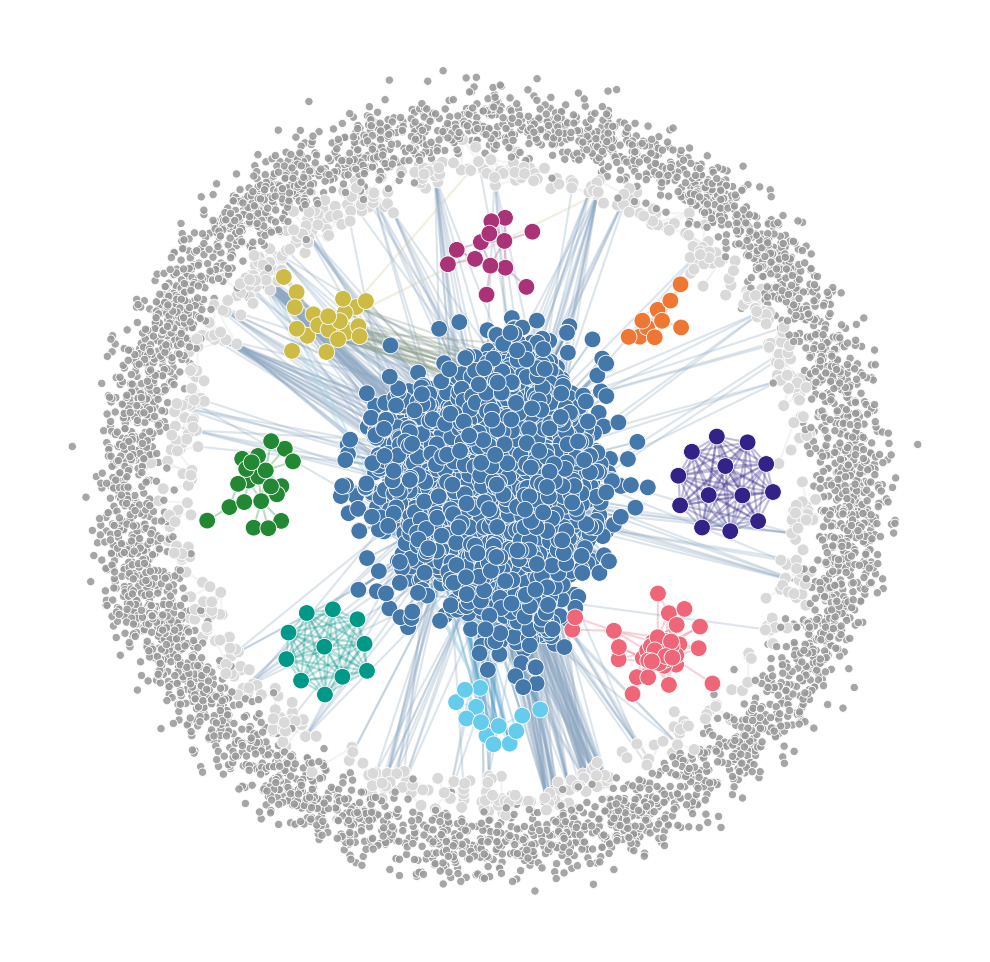

In [ ]:
pos = draw_graph(G, node_color_attribute="Module", edge_size=0.5)

# Save the network plot itself (PNG + PDF) and its node-level data
fig = plt.gcf()
_save(fig, Path(OUT_DIR) / "network_communities.png")

# Save per-node data backing the figure (positions + module + degree + any annotation)
import pandas as pd
_node_rows = []
_pos = pos if pos is not None else {}
_node_attrs = nx.get_node_attributes(G, "Module")
_node_clock = clock_cpgs if "clock_cpgs" in dir() else None
_node_ann = ann if "ann" in dir() and isinstance(ann, dict) else None
for n in G.nodes():
    row = {
        "node": str(n),
        "x": float(_pos.get(n, (float("nan"), float("nan")))[0]),
        "y": float(_pos.get(n, (float("nan"), float("nan")))[1]),
        "Module": _node_attrs.get(n),
        "degree": int(G.degree(n)),
    }
    if _node_clock is not None:
        for clock_name, cpg_set in (_node_clock.items() if isinstance(_node_clock, dict) else []):
            row[f"in_{clock_name}"] = bool(n in cpg_set)
    if _node_ann is not None:
        row["annotation"] = _node_ann.get(n, "")
    _node_rows.append(row)
df_nodes = pd.DataFrame(_node_rows)
_save_data(df_nodes, Path(OUT_DIR) / "network_communities.csv")

# Save the positions for future use
pos_file = 'node_positions.pkl'
with open(pos_file, 'wb') as f:
    pickle.dump(pos, f)
print(f"Saved node positions to {pos_file}.")
